# Vizualizar activaciones intermedias

La visualización de salidas intermedias de una convnet permite identificar como las *convnets* sucesivas transforman la imagen, lo que da una idea de que patrones buscan sus filtros.

Para esta tecnica de interpretavilidad emplearemos el modelo que guardamos en la [seccion 5.2 (*convnet* desde cero con *data augmentation* y *dropout*)](5.2.cats-vs-dogs.ipynb):

In [1]:
from tensorflow import keras

model = keras.models.load_model('./models/cats_and_dogs_small_3.keras')
model.summary()

2026-01-29 19:55:34.617290: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769727335.109150  866226 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769727335.248080  866226 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769727336.624484  866226 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769727336.624572  866226 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769727336.624581  866226 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,906,244 (26.35 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,453,123 (13.17 MB)

Visualizar las activaciones intermedias consiste en mostrar las salidas de varias capas convoucionales y capas *pooling* de una red. 

De cada *feature map* interesa ver 3 dimensiones: alto, ancho y profundidad (canal). Cada canal codifica información relativamente independiente por lo que la es adecuado visualizar cada canal como una imagen 2D independiente.

Vamos a obtener una imagen de un gato que la red no conosca para aplicar la vizualizacion de activaciones intermedias:

(1, 150, 150, 3)


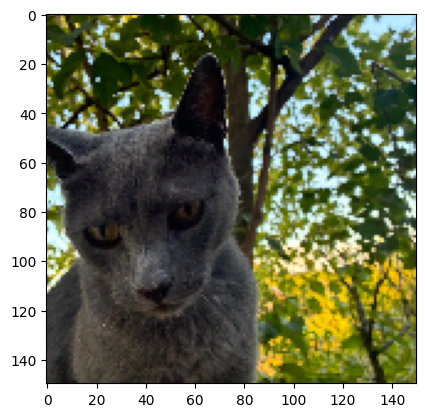

In [9]:
import os

#img_path = os.path.expanduser('~/libros/dlwp/datasets/kaggle_original_data/cats_and_dogs_small/test/cats/cat.1700.jpg')
img_path = os.path.expanduser('~/libros/dlwp/datasets/master-tesis-files/iggy1.jpg')

from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

img = image.load_img(img_path, target_size=(150,150))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

print(img_tensor.shape)

plt.imshow(img_tensor[0])
plt.show()

Crear un modelo que dada una imagen como *input* informe la activacion de cada capa convolucional y de *pooling* como *output*.

In [26]:
from keras import models

layer_outputs = [layer.output for layer in model.layers[:8]]    # Output de 1ras 8 capas.
activation_model = models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

`Model()` a diferencia de `Sequential()` permite multiples salidas.

In [27]:
activations = activation_model.predict(img_tensor)
print(len(activations))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
8


Lo anterior muestra devuelve una lista de 5 arreglos numpy, uno por cada capa convolucional para la imagen del gatos.

1er canal activación de de la primera capa convolucional:

(1, 148, 148, 32)


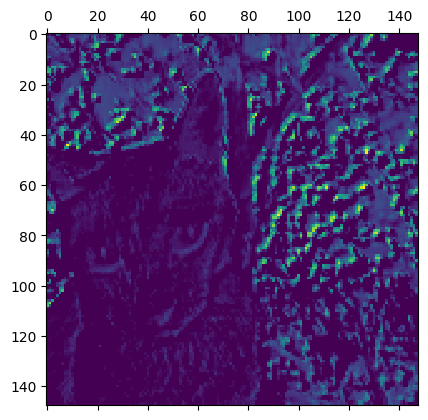

In [28]:
first_layer_activation = activations[0]
print(first_layer_activation.shape)

import matplotlib.pyplot as plt
plt.matshow(first_layer_activation[0, :, :, 1], cmap='viridis')

En verde intenso las areas que detecta, parece codificar areas con colores oscuros. Esto puede variar de ejecución a ejecucion ya que los filtros aprendidos por cada capa convolucion no son deterministas.    

Ahora miramos la activacion del 5to canal:

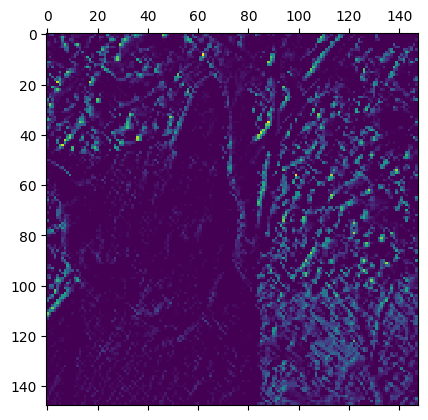

In [29]:
plt.matshow(first_layer_activation[0, :, :, 5], cmap='viridis')

Este canal parece codificar lineas diagonales para ciertos valores, util para detectar pelaje grisaseo.

A continuacion se facilita la visualizacion simultanea de todas las capas de activación:

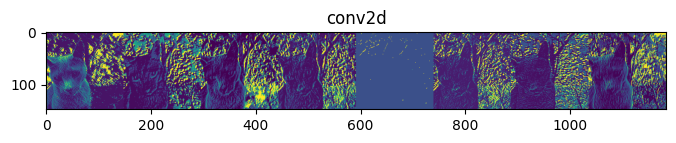

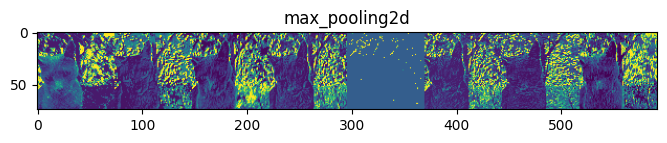

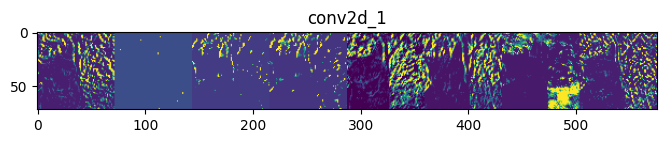

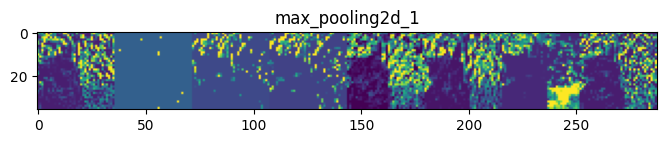

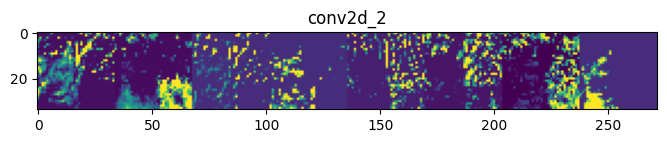

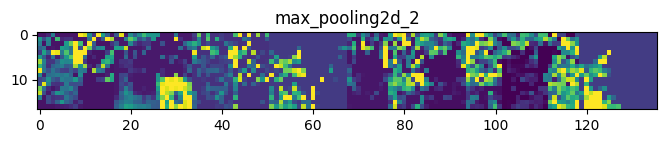

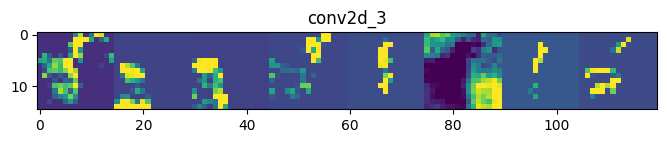

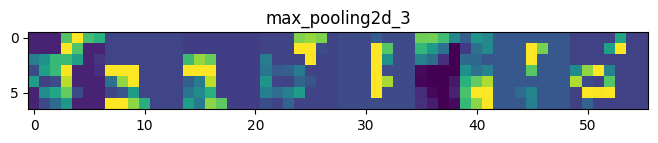

In [31]:
layer_names = []
for layer in model.layers[:8]:
    layer_names.append(layer.name)

images_per_row=8
max_per_level=8

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = min(layer_activation.shape[-1], max_per_level)
    size = layer_activation.shape[1]

    n_rows = n_features // images_per_row
    display_grid = np.zeros((size * n_rows, images_per_row * size))

    for row in range(n_rows):
        for col in range(images_per_row):
            channel_image = layer_activation[0, :, :, row * images_per_row + col]
            # Normalizar heterogeneidad de canales.
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std() 
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[
                row * size : (row + 1) * size,
                col * size : (col + 1) * size] = channel_image
    
    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

Se aprecia como las capas *max_pooling2d* bajan la resolucion de los *feature maps* de su capa anterior.